# Retail Data Wrangling and Analytics

In [1]:
# Import modules 
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

# Load Data from PSQL into DataFrame

**Setup Docker Containers**

![](https://i.imgur.com/VQrBVBk.jpg)

```
#make sure you have both Jupyter and PSQL docker container running
docker ps

#Attach a bridge network to both containers so they can communicate with each other
docker network create jarvis-net
#this command works on running containers
docker network connect jarvis-net jarvis-jupyter
docker network connect jarvis-net jarvis-psql

#verify both containers are attached to the jarvis-net
docker network inspect trading-net

#Note: instead of using `localhost`, you should use container names as hostnames.
```

**Data Preperation**

- Use [pandas.read_sql](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_sql.html) api to load the PSQL retail table into a Pandas DataFrame

![](https://i.imgur.com/AmkAP63.jpg)

- Get familair with the transaction date with `df.head()`, `df.sample(10)`, `df.info()`, `df.describe()`, etc..



In [2]:
#install psql "driver"
!pip3 install psycopg2-binary

     |████████████████████████████████| 3.0 MB 25.7 MB/s eta 0:00:01


In [4]:
import pandas as pd

retail_df = pd.read_csv("online_retail_II.csv")
retail_df.head()


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [5]:
retail_df.info()
retail_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


In [6]:
retail_df.columns = retail_df.columns.str.lower().str.replace(" ", "_")
retail_df.head()


,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [7]:
retail_df["invoicedate"] = pd.to_datetime(retail_df["invoicedate"])
retail_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   invoice      1067371 non-null  object        
 1   stockcode    1067371 non-null  object        
 2   description  1062989 non-null  object        
 3   quantity     1067371 non-null  int64         
 4   invoicedate  1067371 non-null  datetime64[ns]
 5   price        1067371 non-null  float64       
 6   customer_id  824364 non-null   float64       
 7   country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


In [8]:
retail_df["invoice_amount"] = retail_df["quantity"] * retail_df["price"]
retail_df.head()


,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country,invoice_amount
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [9]:
retail_df["year_month"] = retail_df["invoicedate"].dt.to_period("M")
retail_df[["invoicedate","year_month"]].head()


,invoicedate,year_month
0,2009-12-01 07:45:00,2009-12
1,2009-12-01 07:45:00,2009-12
2,2009-12-01 07:45:00,2009-12
3,2009-12-01 07:45:00,2009-12
4,2009-12-01 07:45:00,2009-12


# Load CSV into Dataframe
Alternatively, the LGS IT team also dumped the transactional data into a [CSV file](https://raw.githubusercontent.com/jarviscanada/jarvis_data_eng_demo/feature/data/python_data_wrangling/data/online_retail_II.csv). However, the CSV header (column names) doesn't follow the snakecase or camelcase naming convention (e.g. `Customer ID` instead of `customer_id` or `CustomerID`). As a result, you will need to use Pandas to clean up the data before doing any analytics. In addition, unlike the PSQL scheme, CSV files do not have data types associated. Therefore, you will need to cast/convert certain columns into correct data types (e.g. DateTime, numbers, etc..)

**Data Preperation**

- Read the `data/online_retail_II.csv` file into a DataFrame
- Rename all columns to upper camelcase or snakecase
- Convert/cast all columns to the appropriate data types (e.g. datetime)

In [10]:
retail_df = pd.read_csv("online_retail_II.csv")
retail_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [11]:
retail_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [12]:
retail_df.columns = retail_df.columns.str.lower().str.replace(" ", "_")
retail_df.head()

,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [13]:
retail_df["invoicedate"] = pd.to_datetime(retail_df["invoicedate"])
retail_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   invoice      1067371 non-null  object        
 1   stockcode    1067371 non-null  object        
 2   description  1062989 non-null  object        
 3   quantity     1067371 non-null  int64         
 4   invoicedate  1067371 non-null  datetime64[ns]
 5   price        1067371 non-null  float64       
 6   customer_id  824364 non-null   float64       
 7   country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


# Total Invoice Amount Distribution

In [14]:
retail_df["invoice_amount"] = retail_df["quantity"] * retail_df["price"]
retail_df.head()

,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country,invoice_amount
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [15]:
invoice_total = retail_df.groupby("invoice")["invoice_amount"].sum()
invoice_total.head()

invoice
489434     505.30
489435     145.80
489436     630.33
489437     310.75
489438    2286.24
Name: invoice_amount, dtype: float64

In [16]:
invoice_total.describe()

count     53628.000000
mean        359.648888
std        1654.829288
min     -168469.600000
25%           0.000000
50%         196.345000
75%         403.652500
max      168469.600000
Name: invoice_amount, dtype: float64

In [17]:
invoice_total.mode()

0    0.0
dtype: float64

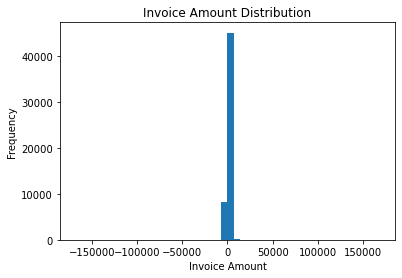

In [18]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(invoice_total, bins=50)
plt.title("Invoice Amount Distribution")
plt.xlabel("Invoice Amount")
plt.ylabel("Frequency")
plt.show()

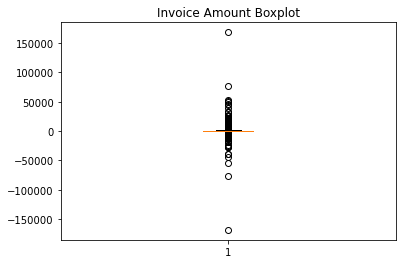

In [19]:
plt.figure()
plt.boxplot(invoice_total)
plt.title("Invoice Amount Boxplot")
plt.show()

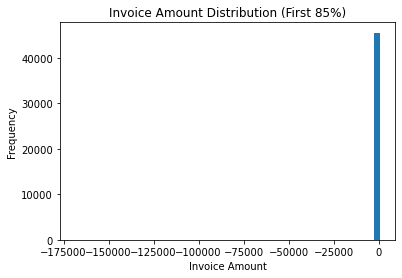

In [20]:
q85 = invoice_total.quantile(0.85)

filtered_invoice = invoice_total[invoice_total <= q85]

plt.figure()
plt.hist(filtered_invoice, bins=50)
plt.title("Invoice Amount Distribution (First 85%)")
plt.xlabel("Invoice Amount")
plt.ylabel("Frequency")
plt.show()

# Monthly Placed and Canceled Orders

In [21]:
retail_df["year_month"] = retail_df["invoicedate"].dt.to_period("M")
retail_df.head()

,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country,invoice_amount,year_month
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009-12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009-12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009-12


In [22]:
retail_df["is_cancelled"] = retail_df["invoice"].astype(str).str.startswith("C")
retail_df.head()

,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country,invoice_amount,year_month,is_cancelled
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009-12,False
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12,False
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12,False
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009-12,False
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009-12,False


In [23]:
monthly_cancelled = retail_df.groupby("year_month")["is_cancelled"].sum()
monthly_cancelled.head()

year_month
2009-12    1015
2010-01     686
2010-02     576
2010-03     844
2010-04     626
Freq: M, Name: is_cancelled, dtype: int64

In [24]:
monthly_total = retail_df.groupby("year_month")["invoice"].nunique()
monthly_total.head()


year_month
2009-12    2330
2010-01    1633
2010-02    1969
2010-03    2367
2010-04    1892
Freq: M, Name: invoice, dtype: int64

In [25]:
monthly_placed = monthly_total - monthly_cancelled
monthly_placed.head()


year_month
2009-12    1315
2010-01     947
2010-02    1393
2010-03    1523
2010-04    1266
Freq: M, dtype: int64

In [26]:
monthly_summary = pd.DataFrame({
    "total_orders": monthly_total,
    "cancelled_orders": monthly_cancelled,
    "placed_orders": monthly_placed
})

monthly_summary.head()


,total_orders,cancelled_orders,placed_orders
year_month,,,
2009-12,2330,1015,1315
2010-01,1633,686,947
2010-02,1969,576,1393
2010-03,2367,844,1523
2010-04,1892,626,1266


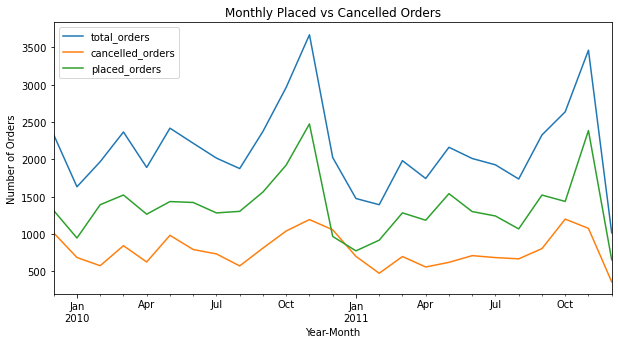

In [27]:
monthly_summary.plot(figsize=(10,5))
plt.title("Monthly Placed vs Cancelled Orders")
plt.xlabel("Year-Month")
plt.ylabel("Number of Orders")
plt.show()


# Monthly Sales

In [28]:
# Monthly net sales (includes cancellations as negative if they exist)
monthly_sales = retail_df.groupby("year_month")["invoice_amount"].sum()
monthly_sales.head()


year_month
2009-12    799847.110
2010-01    624032.892
2010-02    533091.426
2010-03    765848.761
2010-04    590580.432
Freq: M, Name: invoice_amount, dtype: float64

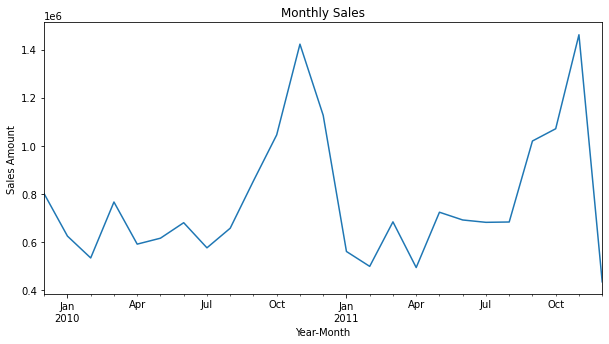

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
monthly_sales.plot()
plt.title("Monthly Sales")
plt.xlabel("Year-Month")
plt.ylabel("Sales Amount")
plt.show()


# Monthly Sales Growth


In [30]:
monthly_sales_growth = monthly_sales.pct_change() * 100
monthly_sales_growth.head()


year_month
2009-12          NaN
2010-01   -21.980978
2010-02   -14.573185
2010-03    43.661804
2010-04   -22.885501
Freq: M, Name: invoice_amount, dtype: float64

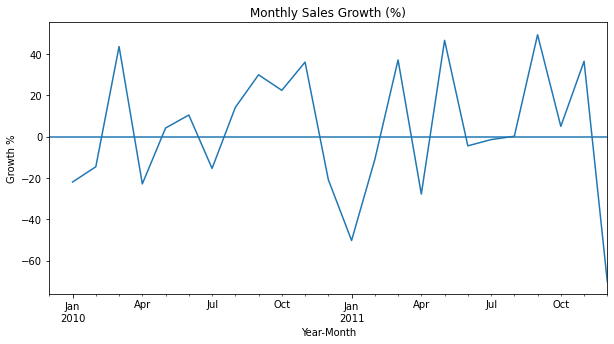

In [31]:
plt.figure(figsize=(10,5))
monthly_sales_growth.plot()
plt.title("Monthly Sales Growth (%)")
plt.xlabel("Year-Month")
plt.ylabel("Growth %")
plt.axhline(0)
plt.show()


# Monthly Active Users

In [32]:
active_users = retail_df[
    (~retail_df["is_cancelled"]) & (retail_df["customer_id"].notna())
].groupby("year_month")["customer_id"].nunique()

active_users.head()


year_month
2009-12     955
2010-01     720
2010-02     774
2010-03    1057
2010-04     942
Freq: M, Name: customer_id, dtype: int64

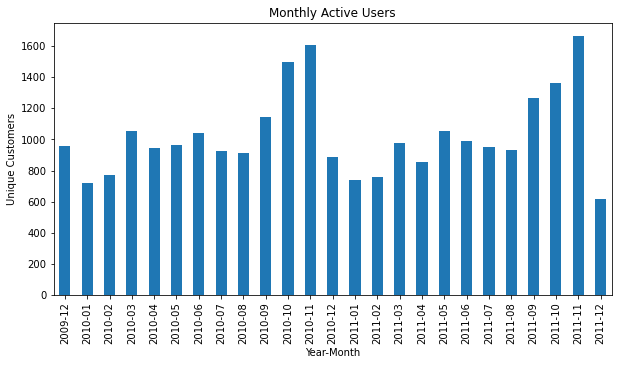

In [33]:
plt.figure(figsize=(10,5))
active_users.plot(kind="bar")
plt.title("Monthly Active Users")
plt.xlabel("Year-Month")
plt.ylabel("Unique Customers")
plt.show()


# New and Existing Users



In [34]:
df_valid = retail_df[(~retail_df["is_cancelled"]) & (retail_df["customer_id"].notna())].copy()

first_month = df_valid.groupby("customer_id")["year_month"].min().rename("first_month")
df_valid = df_valid.join(first_month, on="customer_id")

df_valid[["customer_id", "year_month", "first_month"]].head()


,customer_id,year_month,first_month
0,13085.0,2009-12,2009-12
1,13085.0,2009-12,2009-12
2,13085.0,2009-12,2009-12
3,13085.0,2009-12,2009-12
4,13085.0,2009-12,2009-12


In [35]:
monthly_new_users = df_valid[df_valid["year_month"] == df_valid["first_month"]].groupby("year_month")["customer_id"].nunique()
monthly_existing_users = df_valid[df_valid["year_month"] != df_valid["first_month"]].groupby("year_month")["customer_id"].nunique()

user_summary = (
    monthly_new_users.rename("new_users")
    .to_frame()
    .join(monthly_existing_users.rename("existing_users"), how="outer")
    .fillna(0)
)

user_summary.head()


,new_users,existing_users
year_month,,
2009-12,955,0.0
2010-01,383,337.0
2010-02,376,398.0
2010-03,443,614.0
2010-04,294,648.0


<Figure size 720x360 with 0 Axes>

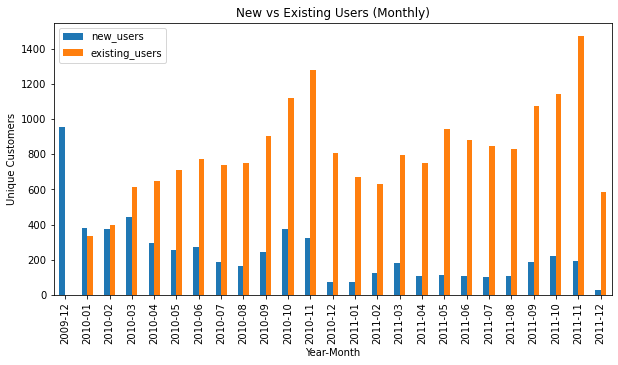

In [36]:
plt.figure(figsize=(10,5))
user_summary.plot(kind="bar", figsize=(10,5))
plt.title("New vs Existing Users (Monthly)")
plt.xlabel("Year-Month")
plt.ylabel("Unique Customers")
plt.show()


In [ ]:
 # Finding RFM

In [37]:
rfm_df = retail_df[(~retail_df["is_cancelled"]) & (retail_df["customer_id"].notna())].copy()

snapshot_date = rfm_df["invoicedate"].max() + pd.Timedelta(days=1)

rfm = rfm_df.groupby("customer_id").agg(
    recency_days=("invoicedate", lambda x: (snapshot_date - x.max()).days),
    frequency=("invoice", "nunique"),
    monetary=("invoice_amount", "sum")
)

rfm.head()


,recency_days,frequency,monetary
customer_id,,,
12346.0,326,12,77556.46
12347.0,2,8,5633.32
12348.0,75,5,2019.40
12349.0,19,4,4428.69
12350.0,310,1,334.40


In [38]:
rfm.describe()


,recency_days,frequency,monetary
count,5881.000000,5881.000000,5881.000000
mean,201.457745,6.287196,3017.076888
std,209.474135,13.012879,14734.128619
min,1.000000,1.000000,0.000000
25%,26.000000,1.000000,347.800000
50%,96.000000,3.000000,897.620000
75%,380.000000,7.000000,2304.180000
max,739.000000,398.000000,608821.650000


# RFM Segmentation

In [39]:
# Score Recency: lower recency_days = better (so we invert scoring)
rfm["r_score"] = pd.qcut(rfm["recency_days"], 5, labels=[5,4,3,2,1])

# Frequency: higher = better
rfm["f_score"] = pd.qcut(rfm["frequency"].rank(method="first"), 5, labels=[1,2,3,4,5])

# Monetary: higher = better
rfm["m_score"] = pd.qcut(rfm["monetary"].rank(method="first"), 5, labels=[1,2,3,4,5])

rfm["rfm_score"] = rfm["r_score"].astype(str) + rfm["f_score"].astype(str) + rfm["m_score"].astype(str)

rfm.head()


,recency_days,frequency,monetary,r_score,f_score,m_score,rfm_score
customer_id,,,,,,,
12346.0,326,12,77556.46,2,5,5,255
12347.0,2,8,5633.32,5,4,5,545
12348.0,75,5,2019.40,3,4,4,344
12349.0,19,4,4428.69,5,3,5,535
12350.0,310,1,334.40,2,1,2,212


In [40]:
rfm["segment"] = "Other"

rfm.loc[(rfm["r_score"].astype(int) >= 4) & (rfm["f_score"].astype(int) >= 4), "segment"] = "Champions"
rfm.loc[(rfm["r_score"].astype(int) >= 4) & (rfm["f_score"].astype(int).between(2,3)), "segment"] = "Potential Loyalists"
rfm.loc[(rfm["r_score"].astype(int).between(2,3)) & (rfm["f_score"].astype(int) >= 4), "segment"] = "Loyal Customers"
rfm.loc[(rfm["r_score"].astype(int) <= 2) & (rfm["f_score"].astype(int) >= 4), "segment"] = "At Risk"
rfm.loc[(rfm["r_score"].astype(int) == 1) & (rfm["f_score"].astype(int) <= 2), "segment"] = "Lost"

rfm["segment"].value_counts()


Other                  1925
Champions              1482
Lost                    890
Potential Loyalists     714
Loyal Customers         516
At Risk                 354
Name: segment, dtype: int64